<h1 align="center"><b>Homework Assignment 5 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 12</b></h3>
<h3 align="center"><b>Due at the end of Module 14</b></h3><br>

---

# Q1 — Study and Summarize *"Attention Is All You Need"*💡
 
## 20 points total

### Objective

- Read and summarize the 2017 paper *"Attention Is All You Need"* (Vaswani et al., NeurIPS 2017), which introduced the Transformer architecture behind modern models such as GPT and BERT. 
- Understand how attention mechanisms replace recurrence, enable efficient parallel training, and transform the design of large-scale generative AI systems.

### What to Include in Your Report

Write a concise report of no more than three pages in your own words that addresses the following:

**A. Motivation** – What limitations of RNNs and CNNs did the Transformer overcome?  
**B. Architecture**
- Summarize the encoder-decoder structure, scaled dot-product attention, and positional encodings. 
- Include one labeled diagram illustrating the Transformer block.  

**C. Training & Efficiency** – Explain how self-attention enables full-sequence parallelization and captures long-range dependencies.  
**D. Results & Impact** – Highlight key translation results and discuss why this work reshaped generative modeling.  
**E. Reflection & Analogy** 
- Provide an example from your own field or area of expertise (e.g., biology, finance, public policy, engineering, etc.) where a Transformer-like attention process could enhance performance or understanding. 
- Map elements of your example to Transformer components (e.g., queries $\rightarrow$ questions, keys $\rightarrow$ evidence, values $\rightarrow$ information sources).

Cite the original paper and any additional references used. References do not count toward the page limit.


---

# Q2 — Mini-Transformer Encoder for Short Texts

## 40 points total

### Objective

Transformers learn relationships between words/tokens using self-attention instead of recurrence as in RNNs. In this problem, you will build and train a Mini-Transformer Encoder to classify short texts from the AG News dataset (4 topics: World, Sports, Business, Sci/Tech). This hands-on task demonstrates how self-attention converts raw word sequences into context-aware representations that capture dependencies between tokens and enable effective topic classification in modern language models.

### [15 points] Part A – Prepare Dataset


__Goal:__ Load, understand and preprocess the AG News dataset for Transformer-based text classification.

1. Use the AG News dataset. (Reference: https://huggingface.co/datasets/fancyzhx/ag_news)

    ``` python
    from datasets import load_dataset  
    dataset = load_dataset("ag_news")
    ```

2. Each sample consists of a short news headline and label (0–3). Confirm label mappings:  0 = World 1 = Sports 2 = Business 3 = Sci/Tech. Show a few examples.
3. Tokenize headlines with a pretrained tokenizer, e.g., `bert-base-uncased` (Reference: https://huggingface.co/docs/transformers/en/tokenizer_summary).
    - Pad or truncate to 24 tokens.
    - Include `[CLS]` at position 0 and `[SEP]` if the tokenizer does so by default.
    - Return ```input_ids``` and ```attention_mask``` (1 for real tokens, 0 for padding).
4. Create train/validation/test splits and Dataloaders.
    - From the provided train split, create 90/10 train/val. Keep the original test set.
    - Build PyTorch DataLoaders with `batch_size = 64` that yield: `input_ids: [B, 24]`, `attention_mask: [B, 24]`, `labels: [B]`

### [15 points] Part B – Implement and Train the Mini-Transformer Encoder


__Goal__: Build a small encoder-only Transformer and train it for 4-way topic classification.

Use PyTorch:
- Token Embedding: `nn.Embedding(vocab_size, d_model=64)` (use the tokenizer’s `vocab_size`).
- Positional Encoding: Add sinusoidal positional encodings to token embeddings.
- Encoder Block: One Pre-LN layer with
    - Multi-Head Self-Attention (2 heads, d_model = 64)
    - Feed-Forward Network (hidden = 128, activation = GELU)
    - Residual + LayerNorm around MHSA and FFN (Pre-LN).
    - Dropout=0.1 applied to attention probs and FFN activations.
    - Padding mask: use `attention_mask` to prevent attending to pads.

- Classifier: Take the contextualized [CLS] token embedding vector at index 0 $\rightarrow$ Linear(64 $\rightarrow$ 4)

Training: 3 epochs with AdamW (`lr = 2e-4`, `weight_decay = 0.01`). Print training and validation accuracy each epoch and final test accuracy.


### [10 points] Part C – Visualize and Reflect


__Goal__: Inspect attention and reason about complexity.

- Attention heatmap: Pick one correctly classified test headline. For one head in the encoder, plot the [24×24] attention weights (query on y-axis, key on x-axis). Label tokens along both axes (use the tokenizer to decode).
- Reflect what you observe:
    - Do higher attention weights align with key topic words?
    - Do higher attention weights land on topic-bearing words (e.g., team names, companies, countries)?
    - Why does self-attention cost as $O(n^2)$ in sequence length $n$?


---

# Q3 — Hybrid AI: Adding Logic Rules to a Neural Model

## 40 points total

### Objective

Understand how symbolic rules can guide neural models toward more consistent and explainable predictions.

### [10 points] Part A – Define a Rule

Write one simple logic rule, e.g.:

- IF income < 20000 THEN loan_approval = False, or
- IF temperature > 38 THEN illness = “fever-related”


### [10 points] Part B — Build a Small Neural Model

1. Create a small synthetic dataset (10–20 samples).
2. Train a simple logistic regression or 1-layer MLP (you may use `sklearn` or `numpy`).
3. Report baseline accuracy.

### [10 points] Part C — Add a Rule Penalty

- Add a check inside training or evaluation:
- If the model violates your rule, add a small penalty (e.g., +1 to loss).
- Show how this affects model output or loss after 5–10 iterations.

### [10 points] Part D — Interpret

Describe:
- How the rule influenced the model’s predictions.
- Why hybrid systems (logic + learning) are more trustworthy.

### Part A – Define a Rule

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

## Part A — Define the rule

**Rule:** IF `income < 20000` THEN `loan_approval = False`

This is a hard business/policy constraint. Regardless what the other features say
(credit score, employment, etc.), approving a loan for someone earning under
$20k violates our lending policy.

Formally:
- Constraint: `income_i < 20000 ⇒ ŷ_i = 0`
- Violation: `income_i < 20000 AND ŷ_i = 1`

## Part B — Synthetic data + baseline model


In [2]:
# 16 samples: [income, credit_score]
# first 3 rows are the interesting ones, low income but great credit.
# without these the baseline never violates the rule and part C is boring
X = np.array([
    [15000, 780],   # tempting violation
    [18000, 750],   # tempting violation
    [12000, 820],   # tempting violation
    [19000, 700],
    [17000, 680],
    [14000, 600],
    [16000, 720],
    [13000, 550],
    [25000, 720],
    [35000, 780],
    [45000, 800],
    [55000, 760],
    [30000, 690],
    [40000, 740],
    [50000, 810],
    [60000, 790],
], dtype=np.float32)

# labels follow the data not the rule — first 3 get approved because credit
# is high, that's the tension we want the rule penalty to resolve later
y = np.array([1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float32)

# standardize so training is stable
X_mean, X_std = X.mean(0), X.std(0)
X_norm = (X - X_mean) / X_std

X_t = torch.tensor(X_norm)
y_t = torch.tensor(y).unsqueeze(1)
income_raw = torch.tensor(X[:, 0])  # need the unscaled income for rule checks


# tiny MLP, basically logistic regression with one hidden layer
class LoanModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4), nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x): return self.net(x)


def train_baseline(epochs=200, lr=0.05):
    model = LoanModel()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(epochs):
        logits = model(X_t)
        loss = bce(logits, y_t)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return model, losses

baseline, baseline_losses = train_baseline()

with torch.no_grad():
    preds = (torch.sigmoid(baseline(X_t)) > 0.5).float().squeeze()

acc_baseline = (preds == y_t.squeeze()).float().mean().item()
violations_baseline = ((income_raw < 20000) & (preds == 1)).sum().item()

print(f"baseline accuracy:  {acc_baseline:.3f}")
print(f"baseline rule violations: {violations_baseline} / {len(y)}")
print("predictions:", preds.int().tolist())
print("true labels:", y_t.squeeze().int().tolist())

/Users/devanpatel/Desktop/AI-Algorithm-Design-and-Analysis---705.623/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


baseline accuracy:  1.000
baseline rule violations: 3 / 16
predictions: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
true labels: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


## Part C — Add the rule penalty


In [3]:
# constraint-guided objective from lecture 13B:
#   L_total = L_pred + λ · L_constraint
# the rule loss penalizes high approval probability whenever income < 20k.
# soft constraint, so it's differentiable and gradients flow through it

def train_with_rule(epochs=200, lr=0.05, lam=2.0):
    model = LoanModel()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    pred_losses, rule_losses, total_losses = [], [], []

    for _ in range(epochs):
        logits = model(X_t)
        probs = torch.sigmoid(logits).squeeze()

        L_pred = bce(logits, y_t)

        # mask out everyone with income >= 20k, then penalize the approval
        # probabilities of whoever's left
        low_income_mask = (income_raw < 20000).float()
        L_rule = (low_income_mask * probs).mean()

        L_total = L_pred + lam * L_rule

        opt.zero_grad(); L_total.backward(); opt.step()

        pred_losses.append(L_pred.item())
        rule_losses.append(L_rule.item())
        total_losses.append(L_total.item())

    return model, pred_losses, rule_losses, total_losses

hybrid, p_losses, r_losses, t_losses = train_with_rule()

with torch.no_grad():
    preds_h = (torch.sigmoid(hybrid(X_t)) > 0.5).float().squeeze()

acc_hybrid = (preds_h == y_t.squeeze()).float().mean().item()
violations_hybrid = ((income_raw < 20000) & (preds_h == 1)).sum().item()

print(f"\nhybrid accuracy:    {acc_hybrid:.3f}")
print(f"hybrid rule violations: {violations_hybrid} / {len(y)}")
print("predictions:", preds_h.int().tolist())

# sside by side so we can see mor eeasily
print("\n  income | true | baseline | hybrid | rule applies?")
print("  " + "-" * 52)
for i in range(len(y)):
    inc = int(X[i, 0])
    rule_low = "YES" if inc < 20000 else "no"
    print(f"  {inc:>6} |  {int(y[i])}   |    {int(preds[i])}     |   {int(preds_h[i])}    | {rule_low}")


hybrid accuracy:    0.875
hybrid rule violations: 1 / 16
predictions: [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]

  income | true | baseline | hybrid | rule applies?
  ----------------------------------------------------
   15000 |  1   |    1     |   0    | YES
   18000 |  1   |    1     |   0    | YES
   12000 |  1   |    1     |   1    | YES
   19000 |  0   |    0     |   0    | YES
   17000 |  0   |    0     |   0    | YES
   14000 |  0   |    0     |   0    | YES
   16000 |  0   |    0     |   0    | YES
   13000 |  0   |    0     |   0    | YES
   25000 |  1   |    1     |   1    | no
   35000 |  1   |    1     |   1    | no
   45000 |  1   |    1     |   1    | no
   55000 |  1   |    1     |   1    | no
   30000 |  1   |    1     |   1    | no
   40000 |  1   |    1     |   1    | no
   50000 |  1   |    1     |   1    | no
   60000 |  1   |    1     |   1    | no


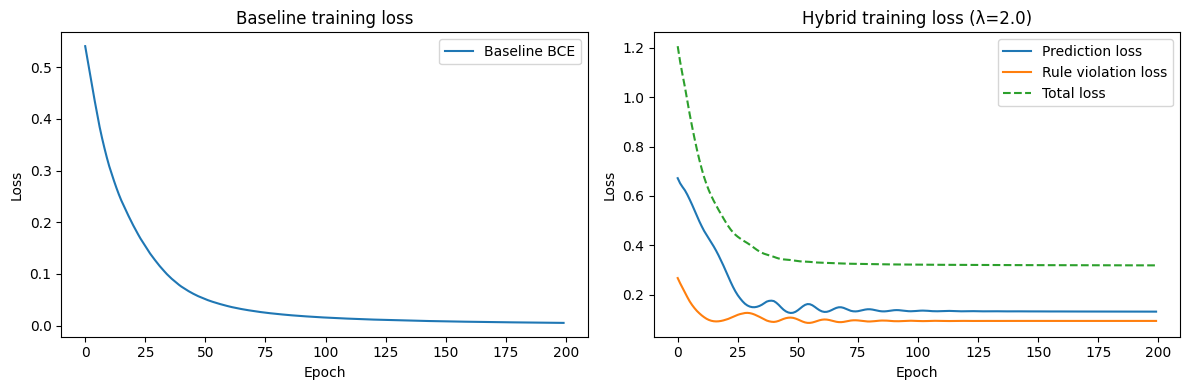

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_losses, label="Baseline BCE")
axes[0].set_title("Baseline training loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(p_losses, label="Prediction loss")
axes[1].plot(r_losses, label="Rule violation loss")
axes[1].plot(t_losses, label="Total loss", linestyle="--")
axes[1].set_title("Hybrid training loss (λ=2.0)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout(); plt.show()